# 04 — Avaliação Final e Explicabilidade

Nesse último notebook eu carrego o melhor modelo que ficou salvo (`models/best_model.pkl`) e analiso **por que ele decide o que decide**.

Uma das partes que achei mais interessante do curso até agora foi descobrir o **SHAP** — uma técnica que mostra, pra cada feature, o quanto ela "empurrou" a predição pra um lado ou pro outro. Num contexto médico isso é fundamental: o médico precisa entender o motivo da decisão do modelo, não só receber o resultado.

Aqui eu vou:
1. Avaliar o modelo final no conjunto de teste.
2. Ver quais features são mais importantes (feature importance + SHAP).
3. Analisar três pacientes específicos: um caso claramente maligno, um claramente benigno, e um caso "em cima do muro".

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import load_data, get_feature_names
from src.preprocessing import split_data
from src.models import load_model
from src.evaluate import evaluate_model
from src.explainability import (
    plot_feature_importance, compute_shap_values, plot_shap_summary,
    plot_shap_bar, plot_shap_waterfall,
)

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


## 1. Carregamento do melhor modelo

In [2]:
df = load_data(save_csv=False)
_, _, X_test, _, _, y_test = split_data(df)
pipeline = load_model('best_model')
metrics = evaluate_model(pipeline, X_test, y_test, model_name='best_model')
print(f'Accuracy: {metrics["accuracy"]:.4f}')
print(f'Recall:   {metrics["recall"]:.4f}')
print(f'F1:       {metrics["f1_score"]:.4f}')
print(f'ROC AUC:  {metrics["roc_auc"]:.4f}')

Accuracy: 0.9649
Recall:   0.9286
F1:       0.9512
ROC AUC:  0.9960


## 2. Feature Importance — top 15

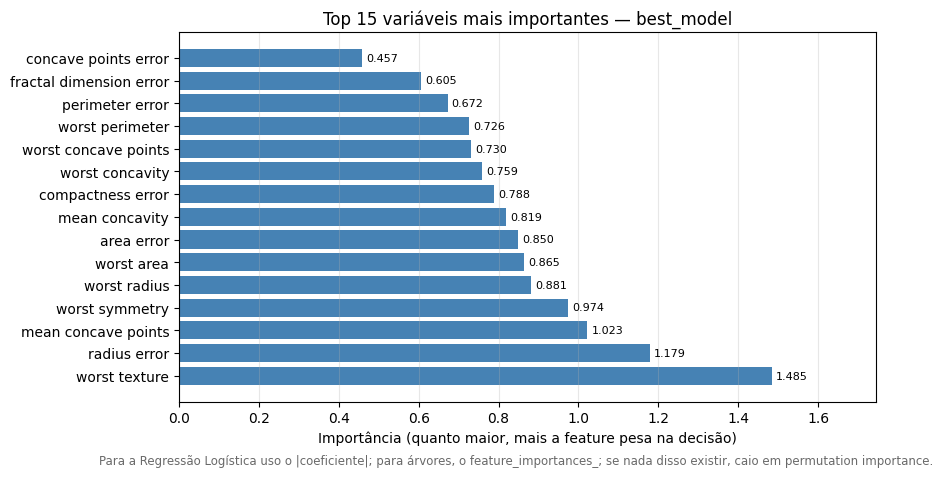

In [3]:
features = get_feature_names()
plot_feature_importance(pipeline, features, model_name='best_model', top_n=15,
                        X_val=X_test, y_val=y_test)
plt.show()

## 3. SHAP Summary Plot (beeswarm)

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


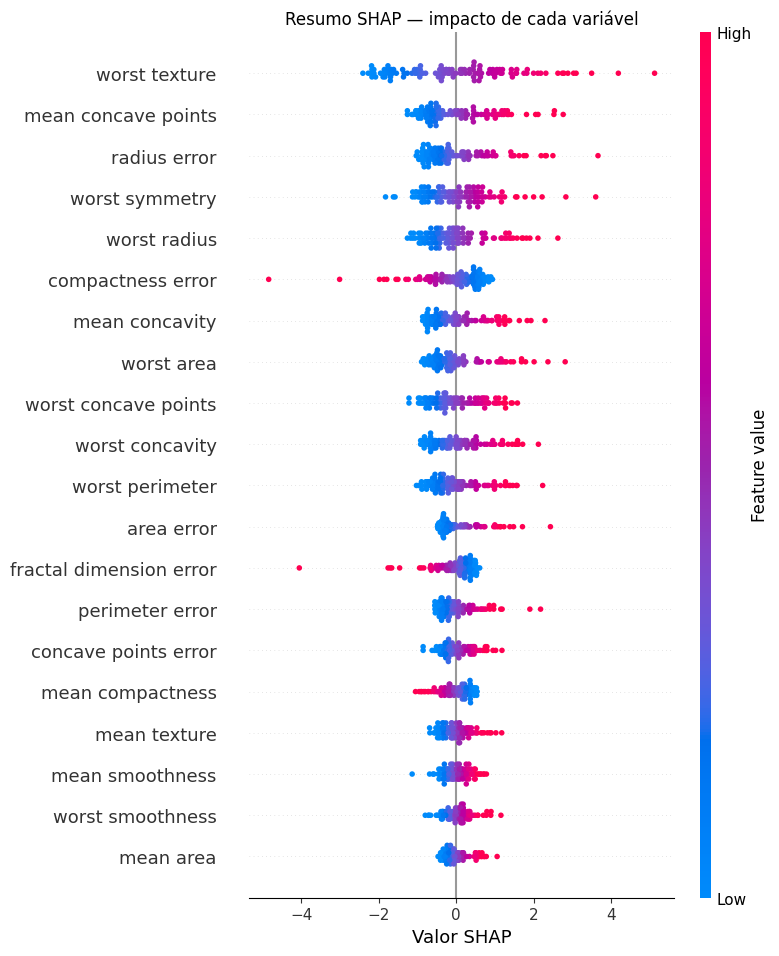

In [4]:
try:
    shap_vals = compute_shap_values(pipeline, X_test, features)
    plot_shap_summary(shap_vals, X_test, features)
    plt.show()
    SHAP_OK = True
except Exception as e:
    SHAP_OK = False
    shap_vals = None
    print(f'[SHAP indisponível neste ambiente]\nMotivo: {e}\n')
    print('As células SHAP serão puladas — feature importance acima continua válida.')

## 4. SHAP Bar Plot — importância média absoluta

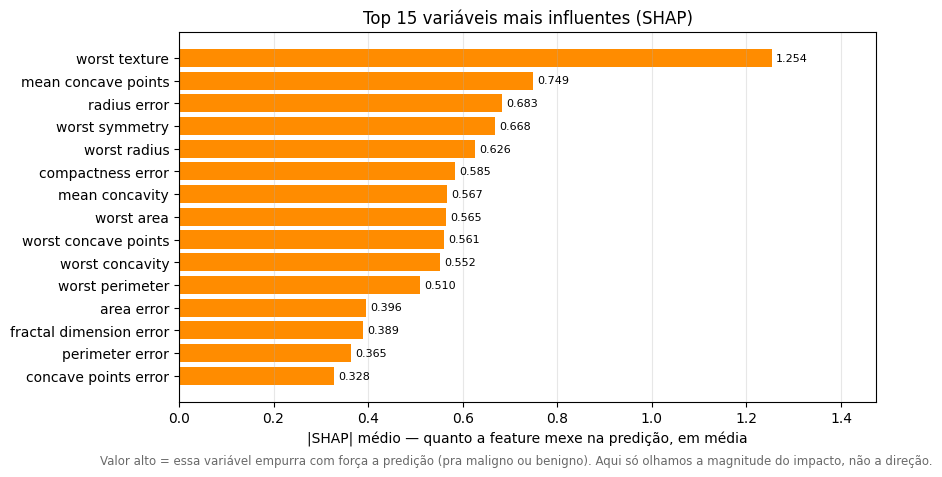

In [5]:
if SHAP_OK:
    plot_shap_bar(shap_vals, features)
    plt.show()
else:
    print('SHAP indisponível — pulando bar plot.')

## 5. SHAP Waterfall — análise de 3 pacientes individuais

In [6]:
preds = pipeline.predict(X_test)
probas = pipeline.predict_proba(X_test)[:, 1]
y_test_arr = y_test.values

tp_idx = next(i for i in range(len(y_test_arr)) if y_test_arr[i] == 1 and preds[i] == 1)
tn_idx = next(i for i in range(len(y_test_arr)) if y_test_arr[i] == 0 and preds[i] == 0)
borderline_candidates = [i for i in range(len(probas)) if 0.45 <= probas[i] <= 0.65]
if borderline_candidates:
    border_idx = borderline_candidates[0]
else:
    border_idx = int(np.argmin(np.abs(probas - 0.5)))

print(f'Verdadeiro positivo  — paciente {tp_idx} (probabilidade de maligno = {probas[tp_idx]:.3f})')
print(f'Verdadeiro negativo — paciente {tn_idx} (probabilidade de maligno = {probas[tn_idx]:.3f})')
print(f'Caso borderline    — paciente {border_idx} (probabilidade de maligno = {probas[border_idx]:.3f})')

Verdadeiro positivo  — paciente 1 (probabilidade de maligno = 1.000)
Verdadeiro negativo — paciente 0 (probabilidade de maligno = 0.000)
Caso borderline    — paciente 3 (probabilidade de maligno = 0.647)


Verdadeiro Positivo (maligno corretamente classificado como maligno):


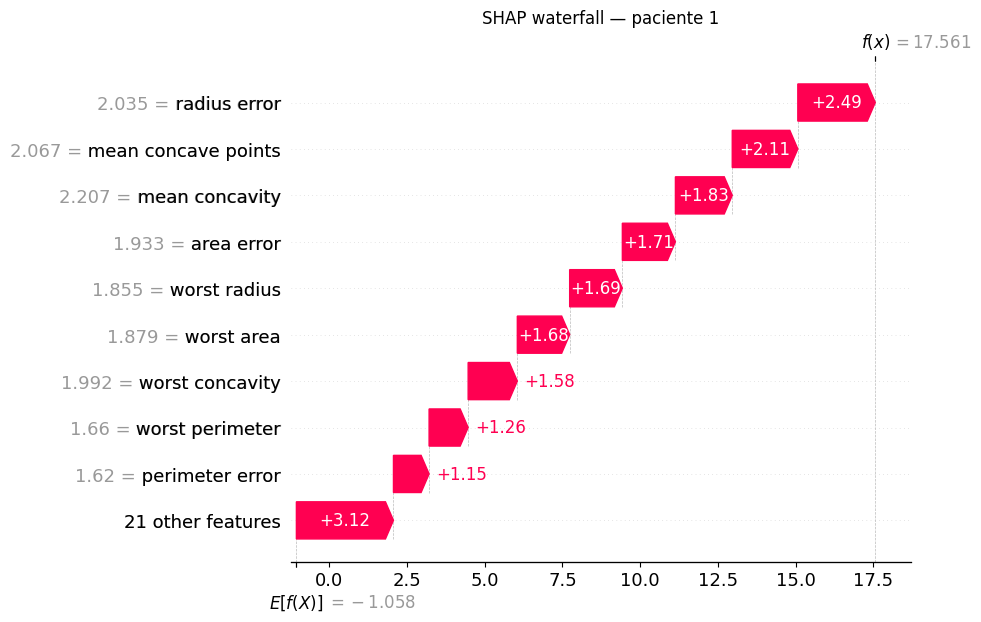

In [7]:
if SHAP_OK:
    print('Verdadeiro Positivo (maligno corretamente classificado como maligno):')
    plot_shap_waterfall(shap_vals, X_test, features, sample_index=tp_idx)
    plt.show()
else:
    print('SHAP indisponível — pulando waterfall do verdadeiro positivo.')

Verdadeiro Negativo (benigno corretamente classificado como benigno):


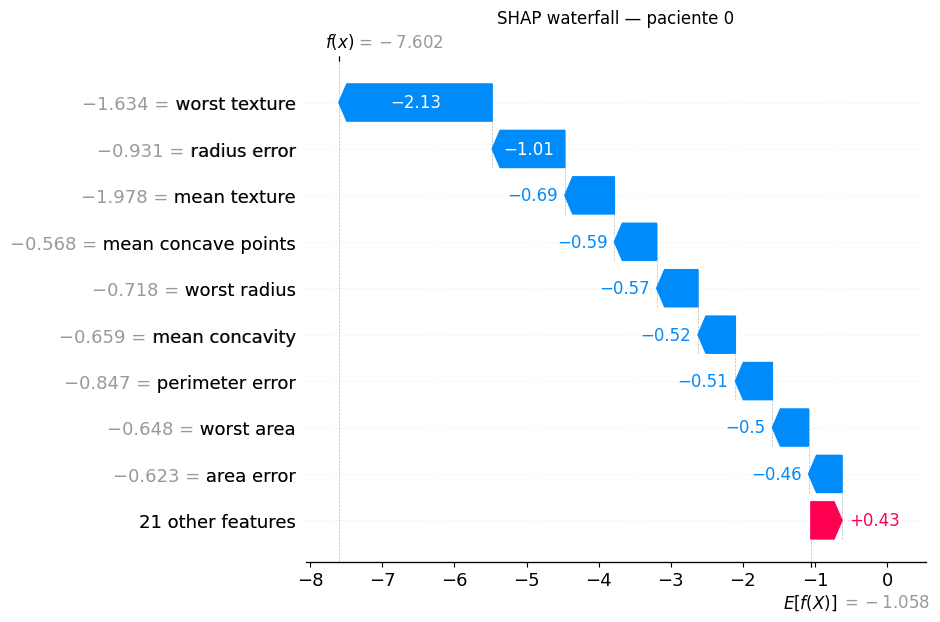

In [8]:
if SHAP_OK:
    print('Verdadeiro Negativo (benigno corretamente classificado como benigno):')
    plot_shap_waterfall(shap_vals, X_test, features, sample_index=tn_idx)
    plt.show()
else:
    print('SHAP indisponível — pulando waterfall do verdadeiro negativo.')

Caso borderline (probabilidade próxima de 0.5 — modelo em dúvida):


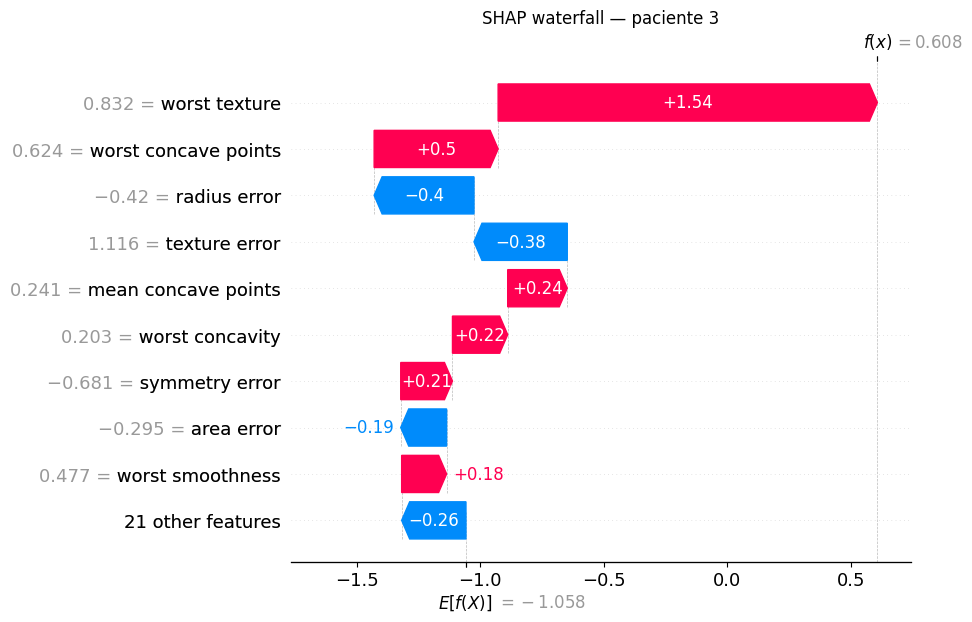

In [9]:
if SHAP_OK:
    print('Caso borderline (probabilidade próxima de 0.5 — modelo em dúvida):')
    plot_shap_waterfall(shap_vals, X_test, features, sample_index=border_idx)
    plt.show()
else:
    print('SHAP indisponível — pulando waterfall do caso borderline.')

## 6. O que as features mais importantes querem dizer

Olhando os gráficos de feature importance e SHAP, as features que mais influenciam a decisão do modelo aparecem repetidamente. A maioria está relacionada com **tamanho e formato irregular** do tumor:

- **`worst concave points` e `mean concave points`** — contam quantas "reentrâncias" o contorno da célula tem. Pelo que li, tumores malignos tendem a ter bordas mais irregulares.
- **`worst perimeter`, `worst radius`, `worst area`** — todas medidas de tamanho. As versões "worst" pegam o maior valor dentro do exame, então captam o pior caso. Tumores grandes têm correlação alta com malignidade.
- **`worst concavity`** — também mede irregularidade, mas em termos de quão profundas são essas reentrâncias.
- **`mean texture`** — variação de intensidade na imagem. Tumores malignos costumam ter textura mais "bagunçada".

O que achei interessante é que o modelo aprendeu sozinho coisas que fazem sentido clínico: **tumor grande + bordas irregulares = mais chance de ser maligno**. Mesmo sem entender de medicina, o modelo chegou em features que profissionais da área usam pra avaliar manualmente. Pra mim isso foi um sinal de que o modelo não está aprendendo "atalhos" estranhos — ele está pegando o sinal real.

## 7. Resumindo tudo

### Esse modelo pode ser usado na prática?

**Como apoio sim, como decisor único não.** Os números são animadores (recall acima de 90% e ROC AUC quase 1.0), mas isso é num dataset bem específico. Não dá pra colocar isso num hospital sem antes:

1. Testar em dados de outros hospitais.
2. Discutir com profissionais da área se as features escolhidas fazem sentido.
3. Ter um plano claro de como o sistema vai ser usado (triagem? segunda opinião?).

### Como eu vejo o uso na rotina

Eu imagino o modelo como uma "ferramenta de organização da fila":

- Casos com alta probabilidade de maligno → vão pra frente da fila, atendimento prioritário.
- Casos claramente benignos → vão pra revisão normal.
- Casos "em cima do muro" (probabilidade entre 0.4 e 0.6) → alerta especial pro médico olhar com mais atenção.

A explicação via SHAP entra em jogo aqui: pra cada caso "borderline" que o modelo marca, o médico pode olhar o gráfico SHAP e ver quais features puxaram pra um lado ou pro outro. Aí ele decide se concorda ou não.

### O trade-off precisão × recall, de novo

Esse é o ponto que eu mais quero deixar claro: **em saúde, prefere-se errar mandando paciente saudável pra exames extras do que deixar paciente doente passar batido.** Por isso o foco em recall. A precisão também importa (não pode mandar todo mundo pra biópsia desnecessariamente), mas se tiver que escolher entre os dois, recall ganha.

### Conclusão pessoal

Foi a primeira vez que montei um projeto de ML inteiro do zero — desde a análise dos dados até a API. O que mais me marcou foram duas coisas:

1. **A escolha da métrica importa muito mais do que eu imaginava.** Olhar só pra acurácia podia me dar uma falsa sensação de modelo bom.
2. **Explicabilidade não é detalhe.** Especialmente em saúde, um modelo "caixa preta" não tem como ser usado de verdade. O SHAP foi a parte que mais mudou como eu enxergo ML.

Sei que ainda tem muito o que melhorar (testar em outro dataset, calibrar probabilidades, montar ensemble), mas pra uma Fase 1 acho que o resultado faz jus ao que foi pedido.